# 목적

선정 기준을 올릴지 말지, 올린다면 얼마나 올려야 할지

- 고객 Lock IN : 선정 기준이 높아져도 고객들이 지속적으로 lock in 될 수 있는가?
- 등급 달성을 위한 매출 업셀링 효과: 선정기준이 높아져도 고객들이 더 구매할 여력이 있는가?
- 유통사의 브랜드 가치 제고: 선정 기준이 높아져서 달성 고객이 줄어들면 더 좋은 등급 브랜딩이 가능하지 않을까?


- 문제 정의
  - VVIP가 추가 구매 여력이 있음에도 등급달성으로 인해 구매하지 않음. CS 발생(등급 달성이 너무 쉬운가)
 
- 구매여력? 등급 달성 후 구매금액 감소 경향

In [6]:
## 최적화 함수로 예측

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

fm.fontManager.ttflist

# 나눔글꼴 경로 설정
font_path = '/Users/jin/AppData/Local/Microsoft/Windows/Fonts/NanumSquareOTF_0.otf'

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 폰트 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus']=False

vvip_long = pd.read_csv("~\side\VVIP\data\VVIP_longform_data.csv")

In [7]:
vvip_long

,cust_id,Date,Sales
0,100003871,2022.1.2,"2,079"
1,100003871,2022.1.5,144
2,100003871,2022.1.7,"3,833"
3,100003871,2022.1.8,"5,919"
4,100003871,2022.1.9,"1,872"
...,...,...,...
390325,772680822,2022.12.15,"15,720"
390326,772680822,2022.12.18,"14,650"
390327,772680822,2022.12.20,530
390328,772680822,2022.12.23,"6,872"


In [8]:
# 전처리(년, 월, 일)

vvip_long["Date"] = pd.to_datetime(vvip_long["Date"], format = "%Y.%m.%d")
vvip_long["year"] = vvip_long["Date"].dt.year
vvip_long["month"] = vvip_long["Date"].dt.month
vvip_long

,cust_id,Date,Sales,year,month
0,100003871,2022-01-02,"2,079",2022,1
1,100003871,2022-01-05,144,2022,1
2,100003871,2022-01-07,"3,833",2022,1
3,100003871,2022-01-08,"5,919",2022,1
4,100003871,2022-01-09,"1,872",2022,1
...,...,...,...,...,...
390325,772680822,2022-12-15,"15,720",2022,12
390326,772680822,2022-12-18,"14,650",2022,12
390327,772680822,2022-12-20,530,2022,12
390328,772680822,2022-12-23,"6,872",2022,12


In [9]:
vvip_long.dtypes

cust_id             int64
Date       datetime64[ns]
Sales              object
year                int32
month               int32
dtype: object

In [10]:
vvip_long["Sales"] = (
    vvip_long["Sales"]
      .str.replace(",", "", regex=False)   # 쉼표 제거
      .astype(int)                         # 정수 변환
)

In [11]:
# 고객 월별 집계 + 누적값

vvip_reduced = (
    vvip_long.groupby(["cust_id", "year", "month"])
      .agg(freq=("Sales", "count"),
           sales=("Sales", "sum"))
      .reset_index()
      .sort_values(["cust_id", "year", "month"])
)

vvip_reduced["cum_sales"] = (
    vvip_reduced.groupby("cust_id")["sales"]
              .cumsum() / 1000
)

vvip_reduced["cum_n_visit"] = (
    vvip_reduced.groupby("cust_id")["freq"]
              .cumsum()
)

vvip_reduced

,cust_id,year,month,freq,sales,cum_sales,cum_n_visit
0,100003871,2022,1,20,28818,28.818,20
1,100003871,2022,2,13,26332,55.150,33
2,100003871,2022,3,15,14710,69.860,48
3,100003871,2022,4,14,5511,75.371,62
4,100003871,2022,5,21,63607,138.978,83
...,...,...,...,...,...,...,...
47305,772342731,2022,12,6,67240,129.448,10
47306,772491531,2022,11,4,124980,124.980,4
47307,772653388,2022,12,3,120900,120.900,3
47308,772680822,2022,11,1,20830,20.830,1


In [12]:
## 로그 회귀선 확인

import statsmodels.api as sm

vvip_reduced["long_visit"] = np.log(vvip_reduced["cum_n_visit"])

X = sm.add_constant(vvip_reduced["long_visit"])
y = vvip_reduced["cum_sales"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              cum_sales   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     5603.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:16:48   Log-Likelihood:            -2.9103e+05
No. Observations:               47310   AIC:                         5.821e+05
Df Residuals:                   47308   BIC:                         5.821e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -24.6759      1.909    -12.926      0.000     -28.418     -20.934
long_visit    38.5749      0.515     74.851      0.000      37.565      39.585
==============================================================================
Omnibus:                    63457.819   Durbin-Watson:                   0.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         23289462.615
Skew:                           7.522   Prob(JB):                         0.00
Kurtosis:                     110.649   Cond. No.                         14.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

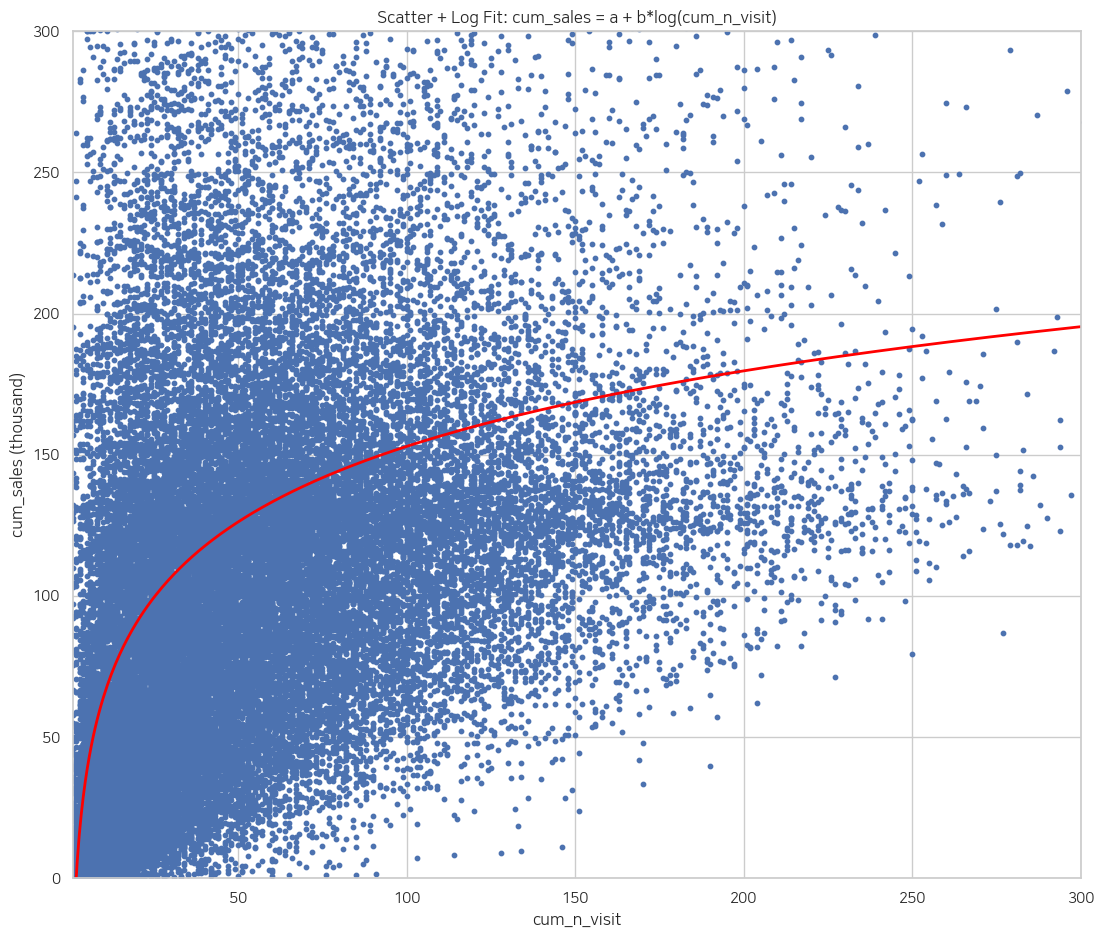

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

a = -24.6759
b = 38.5749

# 그래프 범위
x_min, x_max = 1, 300   # log 때문에 최소 1로
y_min, y_max = 0, 300

# 적합선용 x-grid 만들기
x_grid = np.linspace(x_min, x_max, 500)
y_fit = a + b * np.log(x_grid)

plt.figure(figsize=(13, 11))
plt.scatter(vvip_reduced["cum_n_visit"], vvip_reduced["cum_sales"], s=10)   # 산점도 (색 지정 안 함)
plt.plot(x_grid, y_fit, linewidth=2, color = 'red')                    # 로그 적합선

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("cum_n_visit")
plt.ylabel("cum_sales (thousand)")
plt.title("Scatter + Log Fit: cum_sales = a + b*log(cum_n_visit)")
plt.show()

x = cum_n_visit
→ 각 회원(cust_id)별 누적 방문 횟수

y = cum_sales
→ 각 회원(cust_id)별 누적 매출

로그함수 형식으로 된 걸 볼때 방문은 계속하나 어느시점 이상되면 돈을 쓰지 않음

## 구매 패턴 클러스터링

VVIP 구매이력 파악 후 구매패턴 분류, VVIP 선정 기준 상향 시뮬레이션으로 최적점 도출

In [14]:
aggr = pd.read_csv("~\side\VVIP\data\VVIP_aggr_yearly.csv", encoding = "euc-kr")
aggr

,cust_id,가공식품,가공식품2,남성패션,남성패션2,리빙,리빙2,리빙컨텐츠,리빙컨텐츠2,스포츠팀,...,영패션2,와치주얼리팀,와치주얼리팀2,해외명품팀,해외명품팀2,"해외뷰티,ACC팀","해외뷰티,ACC팀2",F&B,F&B2,매출합계
0,100003871,58.0,"5,868",23.0,"11,893",62.0,"35,483",3.0,578,53,...,"1,331",13.0,"41,102",86.0,"111,769",61.0,"12,120",235.0,"6,820","291,660"
1,100004913,2.0,528,NaN,NaN,35.0,"49,518",1.0,260,8,...,305,4.0,"70,960",18.0,"32,733",5.0,"1,240",57.0,"1,859","163,409"
2,100100021,35.0,"2,981",2.0,"2,317",12.0,"15,182",NaN,NaN,3,...,536,10.0,"115,000",129.0,"448,939",25.0,"27,011",50.0,"2,147","652,408"
3,100120364,20.0,"1,783",NaN,NaN,2.0,146,NaN,NaN,1,...,NaN,NaN,NaN,14.0,"106,365",14.0,"-10,133",41.0,"1,584","111,103"
4,100249228,137.0,"14,949",13.0,"8,779",42.0,"11,225",6.0,"1,373",14,...,78,2.0,"5,775",44.0,"102,192",73.0,"17,971",266.0,"8,380","206,625"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4192,772291617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,"127,600",NaN,NaN,NaN,NaN,NaN,NaN,"127,600"
4193,772342731,1.0,5,1.0,890,NaN,NaN,NaN,NaN,NaN,...,552,9.0,"107,330",3.0,"20,269",1.0,145,7.0,236,"129,447"
4194,772491531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7.0,"124,980",NaN,NaN,NaN,NaN,NaN,NaN,"124,980"
4195,772653388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,6.0,"120,900",NaN,NaN,NaN,NaN,"120,900"


In [15]:
aggr = aggr.drop(aggr.columns[27], axis=1, errors = 'ignore')
aggr

,cust_id,가공식품,가공식품2,남성패션,남성패션2,리빙,리빙2,리빙컨텐츠,리빙컨텐츠2,스포츠팀,...,영패션,영패션2,와치주얼리팀,와치주얼리팀2,해외명품팀,해외명품팀2,"해외뷰티,ACC팀","해외뷰티,ACC팀2",F&B,F&B2
0,100003871,58.0,"5,868",23.0,"11,893",62.0,"35,483",3.0,578,53,...,13.0,"1,331",13.0,"41,102",86.0,"111,769",61.0,"12,120",235.0,"6,820"
1,100004913,2.0,528,NaN,NaN,35.0,"49,518",1.0,260,8,...,1.0,305,4.0,"70,960",18.0,"32,733",5.0,"1,240",57.0,"1,859"
2,100100021,35.0,"2,981",2.0,"2,317",12.0,"15,182",NaN,NaN,3,...,2.0,536,10.0,"115,000",129.0,"448,939",25.0,"27,011",50.0,"2,147"
3,100120364,20.0,"1,783",NaN,NaN,2.0,146,NaN,NaN,1,...,NaN,NaN,NaN,NaN,14.0,"106,365",14.0,"-10,133",41.0,"1,584"
4,100249228,137.0,"14,949",13.0,"8,779",42.0,"11,225",6.0,"1,373",14,...,1.0,78,2.0,"5,775",44.0,"102,192",73.0,"17,971",266.0,"8,380"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4192,772291617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,"127,600",NaN,NaN,NaN,NaN,NaN,NaN
4193,772342731,1.0,5,1.0,890,NaN,NaN,NaN,NaN,NaN,...,1.0,552,9.0,"107,330",3.0,"20,269",1.0,145,7.0,236
4194,772491531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.0,"124,980",NaN,NaN,NaN,NaN,NaN,NaN
4195,772653388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,"120,900",NaN,NaN,NaN,NaN


In [16]:
# cust_id는 범주형
aggr["cust_id"] = aggr["cust_id"].astype("category")

In [17]:
aggr.columns = [
    "cust_id","가공식품","가공식품2", "남성패션","남성패션2", "리빙","리빙2",
    "리빙컨텐츠","리빙컨텐츠2", "스포츠팀","스포츠팀2",
    "신선식품", "신선식품2", "아동테넌트","아동테넌트2", "여성패션","여성패션2",
    "영패션","영패션2", "와치주얼리","와치주얼리2",
    "해외명품","해외명품2", "해외뷰티악세","해외뷰티악세2", "에펜비","에펜비2"
]

In [18]:
# R: ID 제외 NA -> 0
for c in aggr.columns[1:]:
    aggr[c] = pd.to_numeric(aggr[c], errors="coerce").fillna(0)

In [19]:
# ===== 2) Merge similar categories (파생변수 생성) =====
aggr["리빙합"] = aggr["리빙"] + aggr["리빙컨텐츠"]
aggr["장보기식사"] = aggr["가공식품"] + aggr["신선식품"] + aggr["에펜비"]
aggr["명품"] = aggr["와치주얼리"] + aggr["해외명품"]
aggr["패션"] = aggr["남성패션"] + aggr["여성패션"] + aggr["영패션"]
aggr["아동스포츠"] = aggr["스포츠팀"] + aggr["아동테넌트"]
aggr["뷰티악세"] = aggr["해외뷰티악세"]

aggr["리빙합2"] = aggr["리빙2"] + aggr["리빙컨텐츠2"]
aggr["장보기식사2"] = aggr["가공식품2"] + aggr["신선식품2"] + aggr["에펜비2"]
aggr["명품2"] = aggr["와치주얼리2"] + aggr["해외명품2"]
aggr["패션2"] = aggr["남성패션2"] + aggr["여성패션2"] + aggr["영패션2"]
aggr["아동스포츠2"] = aggr["스포츠팀2"] + aggr["아동테넌트2"]
aggr["뷰티악세2"] = aggr["해외뷰티악세2"]

In [20]:
keep_cols = ["cust_id",
             "리빙합","장보기식사","명품","패션","아동스포츠","뷰티악세",
             "리빙합2","장보기식사2","명품2","패션2","아동스포츠2","뷰티악세2"]
aggr = aggr[keep_cols].copy()
feature_cols = aggr.columns[1:]  # cust_id 제외

In [21]:
aggr

,cust_id,리빙합,장보기식사,명품,패션,아동스포츠,뷰티악세,리빙합2,장보기식사2,명품2,패션2,아동스포츠2,뷰티악세2
0,100003871,65.0,344.0,99.0,121.0,75.0,61.0,578.0,0.0,0.0,0.0,0.0,0.0
1,100004913,36.0,62.0,22.0,8.0,8.0,5.0,260.0,1186.0,0.0,305.0,0.0,0.0
2,100100021,12.0,115.0,139.0,19.0,6.0,25.0,0.0,0.0,0.0,536.0,617.0,0.0
3,100120364,2.0,70.0,14.0,8.0,6.0,14.0,146.0,451.0,0.0,0.0,409.0,0.0
4,100249228,48.0,480.0,46.0,52.0,15.0,73.0,0.0,0.0,0.0,78.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4192,772291617,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4193,772342731,0.0,9.0,12.0,2.0,0.0,1.0,0.0,262.0,0.0,1442.0,0.0,145.0
4194,772491531,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4195,772653388,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


C:\Users\jin\AppData\Local\Temp\ipykernel_40208\4098464519.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([aggr[c].values for c in feature_cols], labels=feature_cols, vert=True)


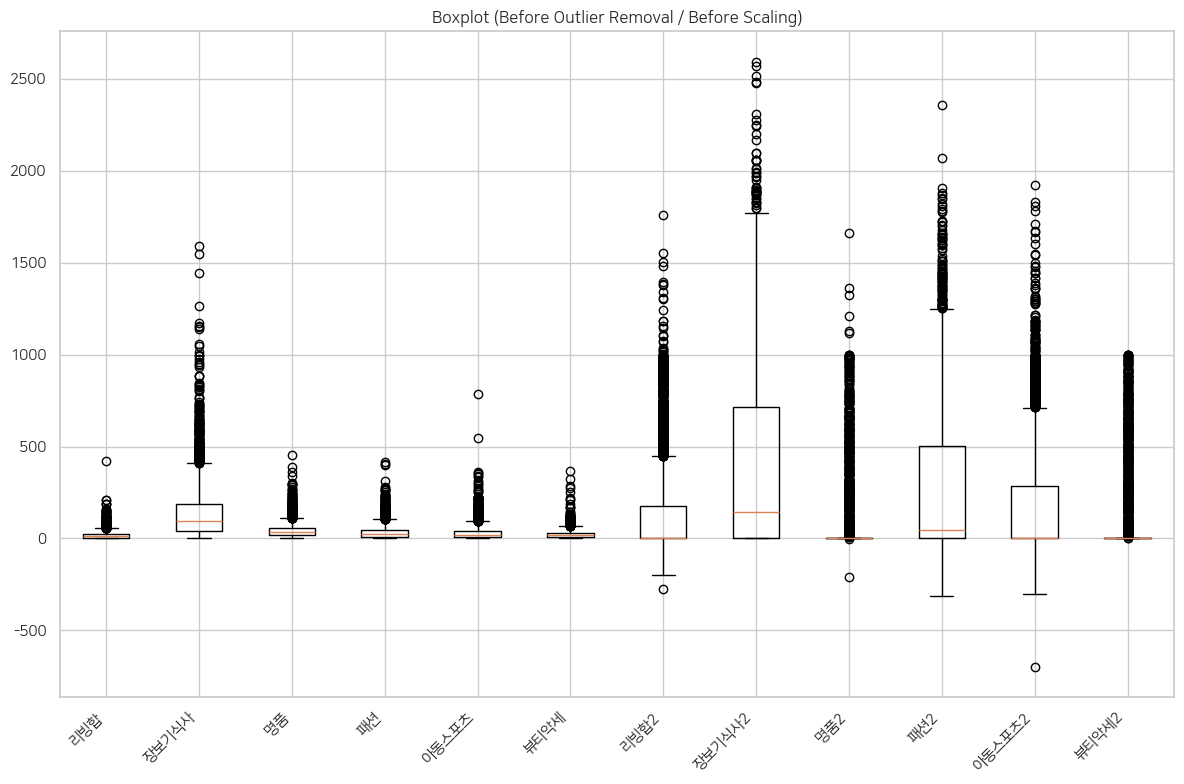

In [22]:
# =========================
# 3. (박스플롯 1) 스케일링 전 박스플롯 확인
# =========================
plt.figure(figsize=(12, 8))
plt.boxplot([aggr[c].values for c in feature_cols], labels=feature_cols, vert=True)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot (Before Outlier Removal / Before Scaling)")
plt.tight_layout()
plt.show()

In [23]:
# =========================
# 4. 이상치 제거 (R 의도: 각 변수별 상위 5명을 outlier로 보고 제거)
#    효율화 버전: 변수별 top5의 cust_id를 모아서 제거(목적에 더 부합)
# =========================
outlier_ids = set()
for c in feature_cols:
    top5_ids = aggr.nlargest(5, c)["cust_id"].astype(str).tolist()
    outlier_ids.update(top5_ids)

aggr_rm = aggr[~aggr["cust_id"].astype(str).isin(outlier_ids)].copy()


In [24]:
# =========================
# 5. Min-Max 스케일링
# =========================
scaler = MinMaxScaler()
X = scaler.fit_transform(aggr_rm[feature_cols].values)

aggr_scaled = pd.DataFrame(X, columns=feature_cols, index=aggr_rm.index)
aggr_scaled.insert(0, "cust_id", aggr_rm["cust_id"].values)

C:\Users\jin\AppData\Local\Temp\ipykernel_40208\192360915.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([aggr_scaled[c].values for c in feature_cols], labels=feature_cols, vert=True)


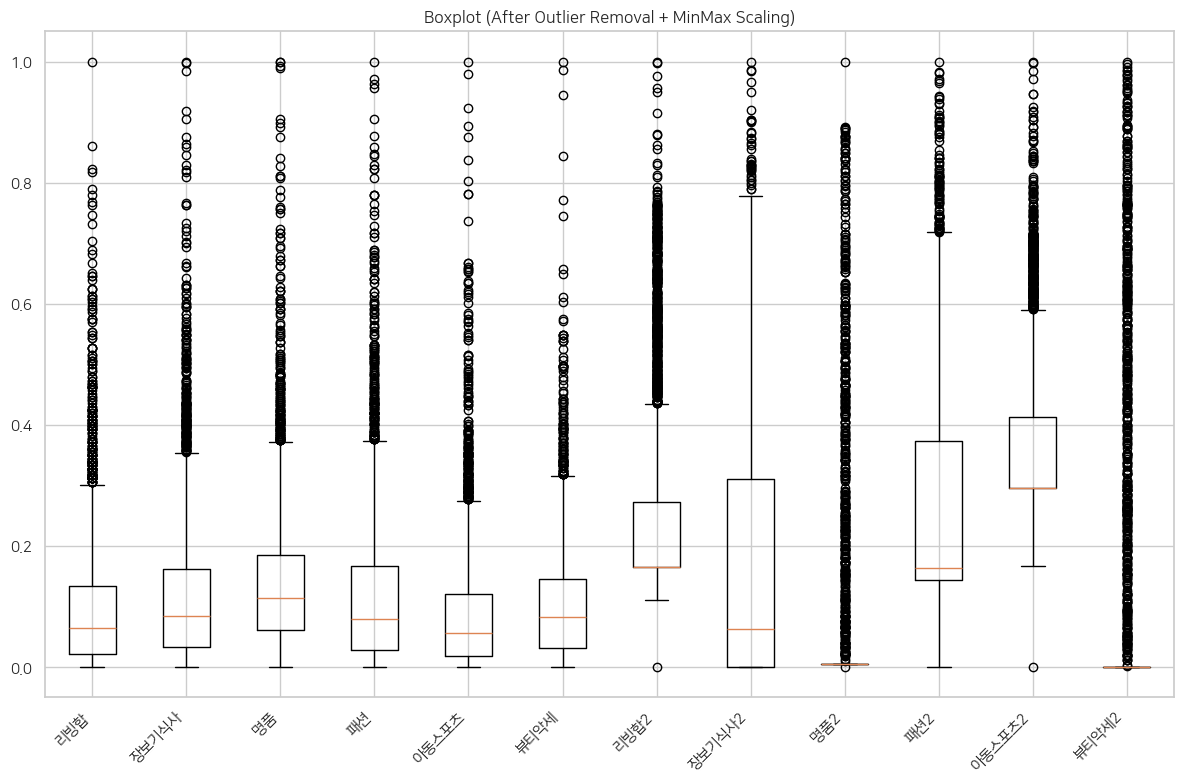

In [25]:
# =========================
# 6. (박스플롯 2) 스케일링 후 박스플롯 확인
# =========================
plt.figure(figsize=(12, 8))
plt.boxplot([aggr_scaled[c].values for c in feature_cols], labels=feature_cols, vert=True)
plt.xticks(rotation=45, ha="right")
plt.title("Boxplot (After Outlier Removal + MinMax Scaling)")
plt.tight_layout()
plt.show()

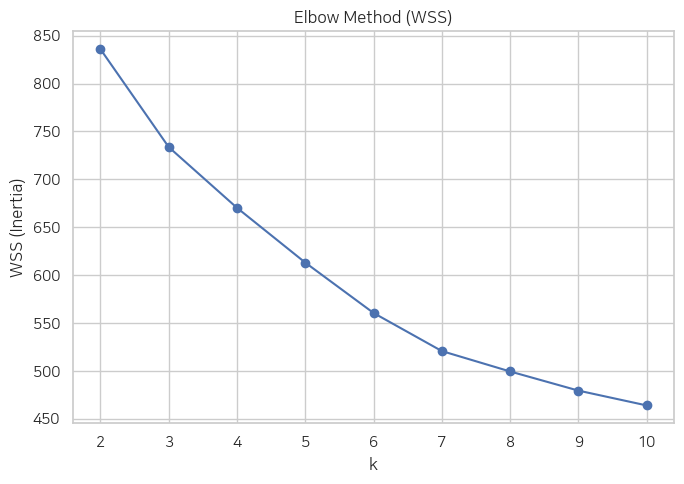

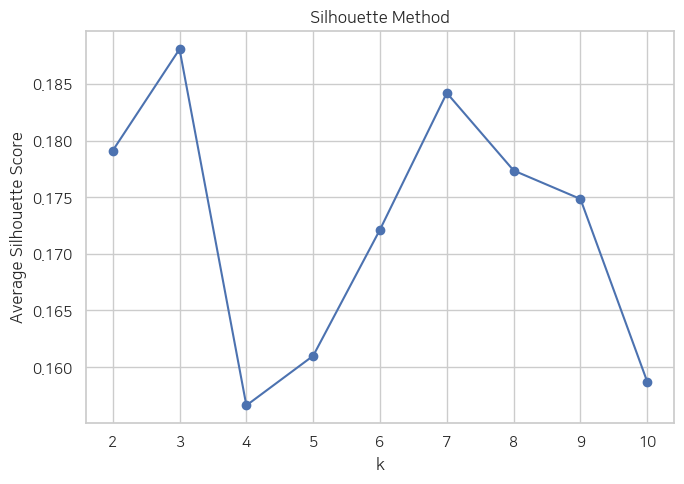

In [26]:
# =========================
# 7. 클러스터 개수 탐색: 엘보우(WSS) + 실루엣
# =========================
X_cluster = aggr_scaled[feature_cols].values

ks = range(2, 11)
wss = []
sil = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=12, n_init=10, max_iter=1000)
    labels = km.fit_predict(X_cluster)
    wss.append(km.inertia_)
    sil.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(7, 5))
plt.plot(list(ks), wss, marker="o")
plt.title("Elbow Method (WSS)")
plt.xlabel("k")
plt.ylabel("WSS (Inertia)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(list(ks), sil, marker="o")
plt.title("Silhouette Method")
plt.xlabel("k")
plt.ylabel("Average Silhouette Score")
plt.tight_layout()
plt.show()

In [27]:
# =========================
# 8. 최종 군집화
# =========================
k = 3
kmeans = KMeans(n_clusters=k, random_state=12, n_init=10, max_iter=1000)
labels = kmeans.fit_predict(X_cluster)

aggr_rm["cluster"] = labels + 1
aggr_scaled["cluster"] = labels + 1

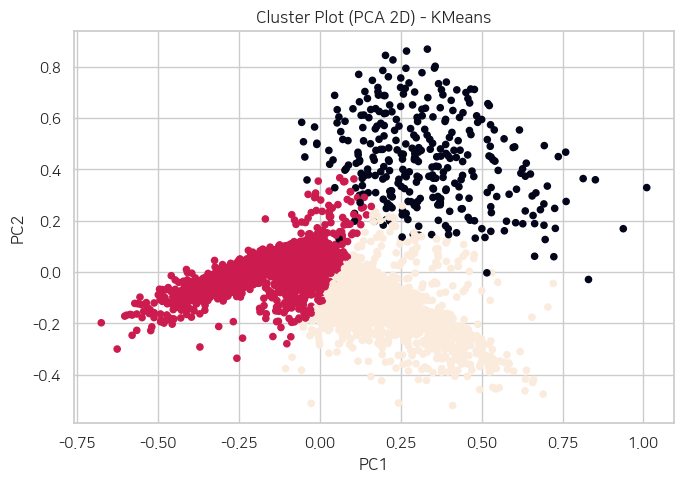

In [28]:
# =========================
# 9. PCA 2D 산점도(클러스터 시각화)
# =========================
pca = PCA(n_components=2, random_state=12)
Z = pca.fit_transform(X_cluster)

plt.figure(figsize=(7, 5))
plt.scatter(Z[:, 0], Z[:, 1], s=20, c=aggr_scaled["cluster"])
plt.title("Cluster Plot (PCA 2D) - KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

### 프로파일링

In [29]:
# 클러스터 분포
print(aggr_rm["cluster"].value_counts().sort_index())
print(aggr_rm["cluster"].dtype)

cluster
1     317
2    2449
3    1375
Name: count, dtype: int64
int32


   cluster  n_customer         패션      아동스포츠       뷰티악세       장보기식사  \
0        1         317  15.813880  18.031546   5.047319   65.611987   
1        2        2449  39.743160  34.534912  27.470396  185.191915   
2        3        1375  25.069818  23.979636  17.688727   71.835636   

         리빙합         명품         패션2      아동스포츠2       뷰티악세2      장보기식사2  \
0   9.072555  36.539432  298.671924  225.659306  622.839117  597.624606   
1  22.499388  43.048183  246.083299  163.230706    6.068191   63.938751   
2  12.500364  39.664727  319.304727  212.437818   14.436364  916.374545   

         리빙합2        명품2  
0  146.835962  39.968454  
1  140.170682  50.394038  
2  138.458182  35.776000  


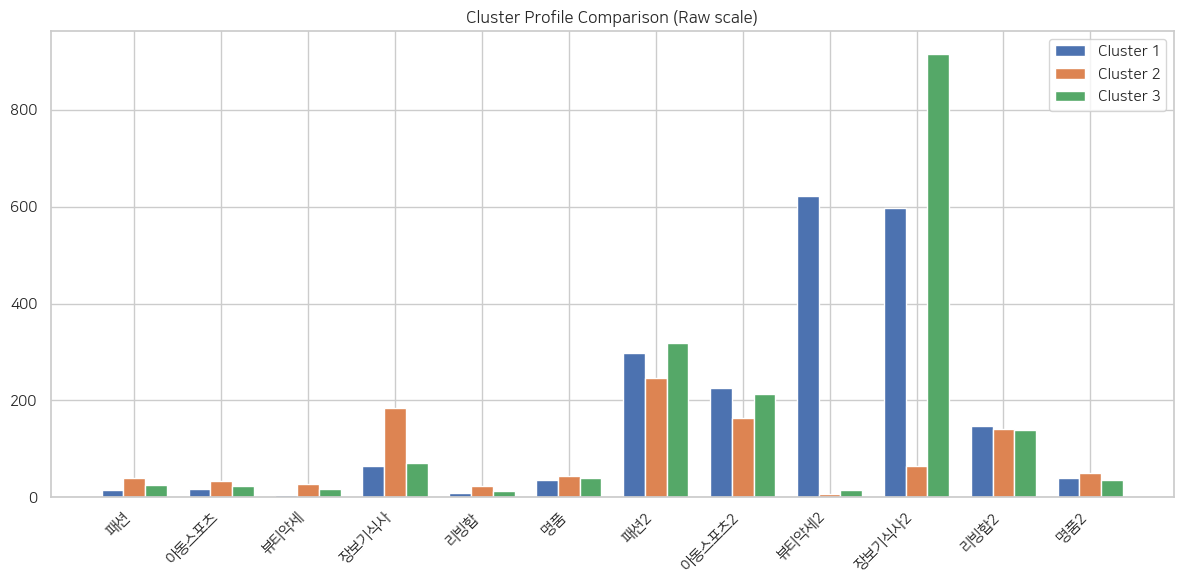

In [30]:
feature_cols = [
    "패션","아동스포츠","뷰티악세","장보기식사","리빙합","명품",
    "패션2","아동스포츠2","뷰티악세2","장보기식사2","리빙합2","명품2"
]

# 클러스터별 평균 + 고객수
aggr_sum = (
    aggr_rm.groupby("cluster")
         .agg(n_customer=("cust_id", "count"), **{c:(c,"mean") for c in feature_cols})
         .reset_index()
)

print(aggr_sum)

# wide -> long
aggr_long = aggr_sum.melt(id_vars=["cluster","n_customer"], value_vars=feature_cols,
                      var_name="var", value_name="value")

# facet(클러스터별) 막대그래프: 각 클러스터마다 별도 figure로 그리는 방식(가장 확실)
plt.figure(figsize=(12,6))

clusters = sorted(aggr_long["cluster"].unique())
x = np.arange(len(feature_cols))
width = 0.25

for i, cl in enumerate(clusters):
    tmp = aggr_long[aggr_long["cluster"] == cl]
    plt.bar(x + i*width, tmp["value"], width=width, label=f"Cluster {cl}")

plt.xticks(x + width, feature_cols, rotation=45, ha="right")
plt.legend()
plt.title("Cluster Profile Comparison (Raw scale)")
plt.tight_layout()
plt.show()

   cluster  n_customer        패션     아동스포츠      뷰티악세     장보기식사       리빙합  \
0        1         317  0.057297  0.053190  0.023047  0.056807  0.048777   
1        2        2449  0.143997  0.101873  0.125436  0.160339  0.120964   
2        3        1375  0.090833  0.070736  0.080770  0.062195  0.067206   

         명품       패션2    아동스포츠2     뷰티악세2    장보기식사2      리빙합2       명품2  
0  0.123444  0.282397  0.390244  0.629130  0.262231  0.254578  0.039972  
1  0.145433  0.258118  0.363925  0.006129  0.028056  0.250556  0.049239  
2  0.134002  0.291923  0.384670  0.014582  0.402095  0.249522  0.036245  


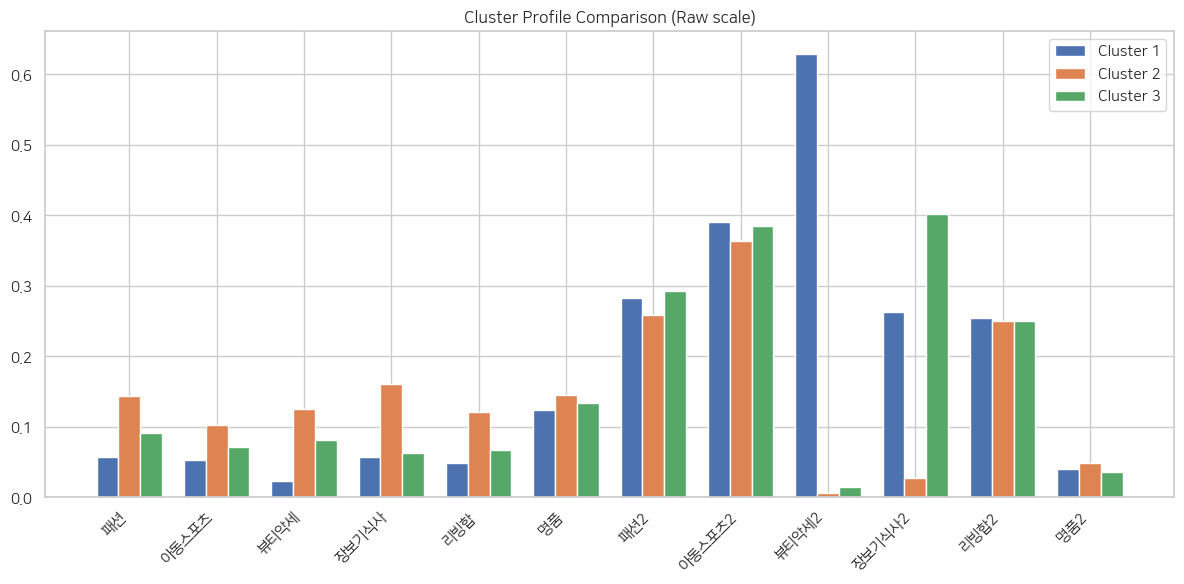

In [31]:
aggr_sum2 = (
    aggr_scaled.groupby("cluster")
             .agg(n_customer=("cust_id", "count"), **{c:(c,"mean") for c in feature_cols})
             .reset_index()
)

print(aggr_sum2)

aggr_long2 = aggr_sum2.melt(id_vars=["cluster","n_customer"], value_vars=feature_cols,
                        var_name="var", value_name="value")

plt.figure(figsize=(12,6))

clusters = sorted(aggr_long2["cluster"].unique())
x = np.arange(len(feature_cols))
width = 0.25

for i, cl in enumerate(clusters):
    tmp = aggr_long2[aggr_long2["cluster"] == cl]
    plt.bar(x + i*width, tmp["value"], width=width, label=f"Cluster {cl}")

plt.xticks(x + width, feature_cols, rotation=45, ha="right")
plt.legend()
plt.title("Cluster Profile Comparison (Raw scale)")
plt.tight_layout()
plt.show()

In [32]:
aggr_indiv = pd.read_csv("~\side\VVIP\data\VVIP_indiv_info.csv", encoding="euc-kr")
aggr_indiv["cust_id"] = aggr_indiv["cust_id"].astype(str)

# join을 위해 cust_id 타입 맞추기
aggr_joined = aggr_rm.copy()
aggr_joined["cust_id"] = aggr_joined["cust_id"].astype(str)

aggr_joined = aggr_joined.merge(aggr_indiv, on="cust_id", how="left")

# NA 확인
print(aggr_joined.isna().sum())

# 편의: 합계 변수 (R에서 sum(리빙합2 + ...) 형태)
sales_cols = ["리빙합2","장보기식사2","명품2","패션2","아동스포츠2","뷰티악세2"]
cnt_cols   = ["리빙합","장보기식사","명품","패션","아동스포츠","뷰티악세"]

aggr_joined["매출합_row"] = aggr_joined[sales_cols].sum(axis=1)
aggr_joined["건수합_row"] = aggr_joined[cnt_cols].sum(axis=1)

# 강남/서초 비율용 boolean
aggr_joined["강남서초_flag"] = aggr_joined["Geo"].isin(["Gangnam","Seocho"]).astype(int)

# 연령대 플래그
aggr_joined["is_20s"] = ((aggr_joined["Age"] >= 20) & (aggr_joined["Age"] < 30)).astype(int)
aggr_joined["is_30s"] = ((aggr_joined["Age"] >= 30) & (aggr_joined["Age"] < 40)).astype(int)
aggr_joined["is_40s"] = ((aggr_joined["Age"] >= 40) & (aggr_joined["Age"] < 50)).astype(int)
aggr_joined["is_50s"] = ((aggr_joined["Age"] >= 50) & (aggr_joined["Age"] < 60)).astype(int)
aggr_joined["is_60p"] = (aggr_joined["Age"] >= 60).astype(int)

# 클러스터별 요약
summary = (
    aggr_joined.groupby("cluster")
    .agg(
        리빙건수=("리빙합","mean"),
        장보기건수=("장보기식사","mean"),
        명품건수=("명품","mean"),
        패션건수=("패션","mean"),
        아동스포츠건수=("아동스포츠","mean"),
        뷰티악세건수=("뷰티악세","mean"),

        리빙매출=("리빙합2","mean"),
        장보기매출=("장보기식사2","mean"),
        명품매출=("명품2","mean"),
        패션매출=("패션2","mean"),
        아동스포츠매출=("아동스포츠2","mean"),
        뷰티악세매출=("뷰티악세2","mean"),

        나이=("Age","mean"),
        인원수=("cust_id","count"),
        강남서초=("강남서초_flag","mean"),

        매출합=("매출합_row","sum"),
        건수합=("건수합_row","sum"),

        비율_20대=("is_20s","mean"),
        비율_30대=("is_30s","mean"),
        비율_40대=("is_40s","mean"),
        비율_50대=("is_50s","mean"),
        비율_60대이상=("is_60p","mean"),
    )
    .reset_index()
)

# R에서는 강남서초, 연령비율을 *100 했으니 동일하게 변환
pct_cols = ["강남서초","비율_20대","비율_30대","비율_40대","비율_50대","비율_60대이상"]
summary[pct_cols] = (summary[pct_cols] * 100).round(2)

# 객단가/건단가/인당건수 (R에서 sum(...) / n() 같은 정의)
summary["객단가"] = (summary["매출합"] / summary["인원수"]).round(3)
summary["건단가"] = (summary["매출합"] / summary["건수합"]).replace([np.inf, -np.inf], np.nan).round(3)
summary["인당건수"] = (summary["건수합"] / summary["인원수"]).round(3)

# 평균값들도 보기 좋게 반올림
mean_cols_to_round = [
    "리빙건수","장보기건수","명품건수","패션건수","아동스포츠건수","뷰티악세건수",
    "리빙매출","장보기매출","명품매출","패션매출","아동스포츠매출","뷰티악세매출",
    "나이","매출합","건수합"
]
summary[mean_cols_to_round] = summary[mean_cols_to_round].round(3)


cust_id    0
리빙합        0
장보기식사      0
명품         0
패션         0
아동스포츠      0
뷰티악세       0
리빙합2       0
장보기식사2     0
명품2        0
패션2        0
아동스포츠2     0
뷰티악세2      0
cluster    0
Geo        0
Age        0
dtype: int64


In [33]:
summary

,cluster,리빙건수,장보기건수,명품건수,패션건수,아동스포츠건수,뷰티악세건수,리빙매출,장보기매출,명품매출,...,매출합,건수합,비율_20대,비율_30대,비율_40대,비율_50대,비율_60대이상,객단가,건단가,인당건수
0,1,9.073,65.612,36.539,15.814,18.032,5.047,146.836,597.625,39.968,...,612317.0,47587.0,0.63,21.14,36.28,23.34,18.61,1931.599,12.867,150.117
1,2,22.499,185.192,43.048,39.743,34.535,27.470,140.171,63.939,50.394,...,1640550.0,863243.0,0.57,8.90,24.50,30.42,35.61,669.886,1.900,352.488
2,3,12.500,71.836,39.665,25.070,23.980,17.689,138.458,916.375,35.776,...,2250583.0,262266.0,1.02,15.78,33.38,27.27,22.55,1636.788,8.581,190.739


,cluster,대상_명,대상_%,매출,매출_%,평균건수,평균연령
0,1,317,7.66,612317.0,13.60,150.117,48.87
1,2,2449,59.14,1640550.0,36.43,352.488,54.84
2,3,1375,33.20,2250583.0,49.97,190.739,50.56


,cluster,대상_명,대상_%,매출_억,매출_%,객단가_TOP1_억,평균건수,평균연령
0,1,317,7.66,0.01,13.60,0.0,150.117,48.87
1,2,2449,59.14,0.02,36.43,0.0,352.488,54.84
2,3,1375,33.20,0.02,49.97,0.0,190.739,50.56


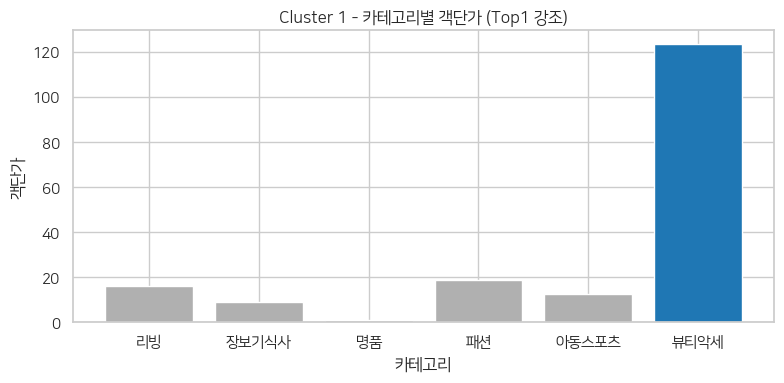

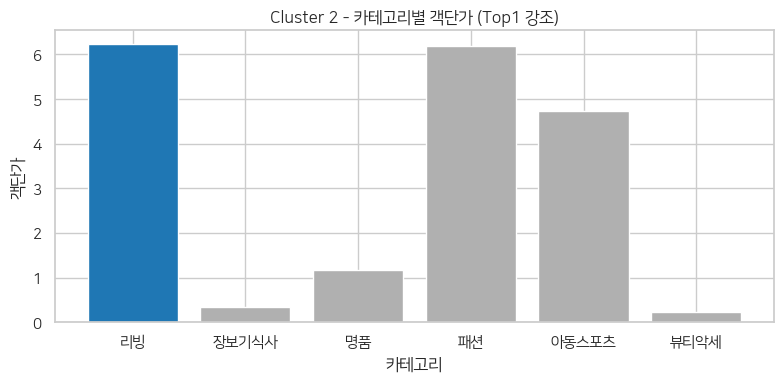

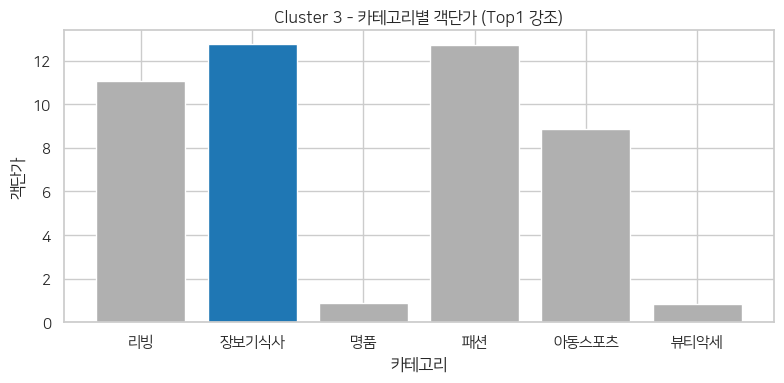

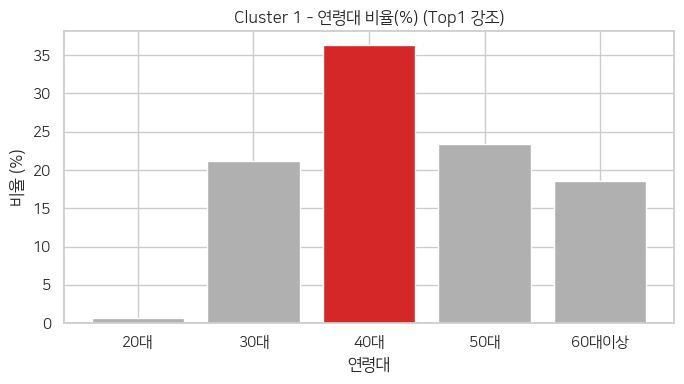

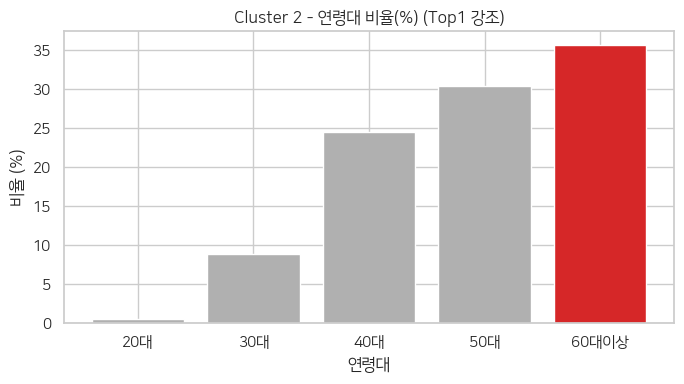

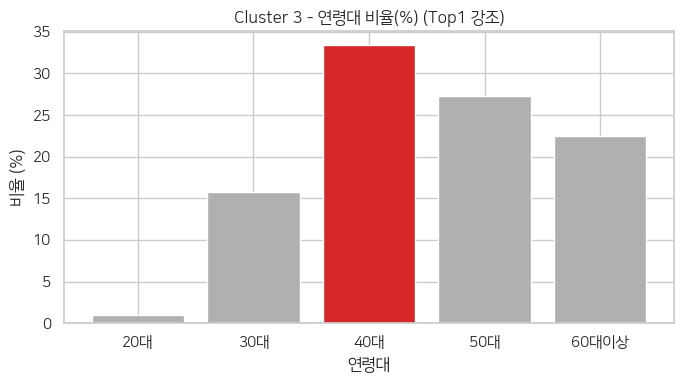

In [39]:
# =========================
# 0) 전체 분모(전체 고객수/전체 매출) - ipynb 데이터 구조(고객 1행) 기준
# =========================
total_customers = aggr_joined["cust_id"].nunique()
total_sales = aggr_joined["매출합_row"].sum()

# =========================
# 1) 표용 요약(클러스터별)
#    1. 대상 (명, %)
#    2. 매출 (원본단위, %)
#    5. 평균건수
#    6. 평균연령
# =========================
summary2 = summary.copy()

total_customers = aggr_joined["cust_id"].nunique()
total_sales = aggr_joined["매출합_row"].sum()

summary2["대상_명"] = summary2["인원수"]
summary2["대상_%"] = (summary2["인원수"] / total_customers * 100).round(2)

summary2["매출"] = summary2["매출합"]          # ✅ 원본 단위 그대로
summary2["매출_%"] = (summary2["매출합"] / total_sales * 100).round(2)

summary2["평균건수"] = summary2["인당건수"].round(3)
summary2["평균연령"] = summary2["나이"].round(2)

final_cols = ["cluster", "대상_명", "대상_%", "매출", "매출_%", "평균건수", "평균연령"]
display(summary2[final_cols].sort_values("cluster"))

# -------------------------
# (핵심) 클러스터별 TOP1 고객 매출 계산 → 객단가_TOP1_억 만들기
# -------------------------
top1_customer = (
    aggr_joined.groupby("cluster")["매출합_row"]
    .max()
    .reset_index()
)
top1_customer["객단가_TOP1_억"] = (top1_customer["매출합_row"] / divisor_for_eok).round(2)
top1_customer = top1_customer[["cluster", "객단가_TOP1_억"]]

# merge 전에 혹시 기존 컬럼 있으면 제거(중복 suffix 방지)
if "객단가_TOP1_억" in summary2.columns:
    summary2 = summary2.drop(columns=["객단가_TOP1_억"])

summary2 = summary2.merge(top1_customer, on="cluster", how="left")

# -------------------------
# 최종 출력 (없으면 자동으로 빼고 보여주기)
# -------------------------
final_cols = [
    "cluster",
    "대상_명","대상_%",
    "매출_억","매출_%",
    "객단가_TOP1_억",
    "평균건수","평균연령"
]

# 실제 존재하는 컬럼만 출력 (또 KeyError 나지 않게)
final_cols_exist = [c for c in final_cols if c in summary2.columns]
display(summary2[final_cols_exist].sort_values("cluster"))

# ============================================================
# 4) 클러스터별 "카테고리명(x) - 객단가(y)" 그래프 (클러스터당 1개)
#    - 객단가(카테고리) = (클러스터 내 해당 카테고리 매출합 총합) / (클러스터 내 해당 카테고리 건수합 총합)
#    - y값 최상위 1개 카테고리만 색 다르게
# ============================================================
sales_cols = ["리빙합2","장보기식사2","명품2","패션2","아동스포츠2","뷰티악세2"]
cnt_cols   = ["리빙합","장보기식사","명품","패션","아동스포츠","뷰티악세"]

cat_map = {
    "리빙": ("리빙합2", "리빙합"),
    "장보기식사": ("장보기식사2", "장보기식사"),
    "명품": ("명품2", "명품"),
    "패션": ("패션2", "패션"),
    "아동스포츠": ("아동스포츠2", "아동스포츠"),
    "뷰티악세": ("뷰티악세2", "뷰티악세"),
}
cat_order = list(cat_map.keys())

clusters = sorted(aggr_joined["cluster"].unique())

for cl in clusters:
    df_cl = aggr_joined[aggr_joined["cluster"] == cl].copy()

    rows = []
    for cat in cat_order:
        s_col, c_col = cat_map[cat]
        sales_sum = df_cl[s_col].sum()
        cnt_sum = df_cl[c_col].sum()
        unit = np.nan if cnt_sum == 0 else sales_sum / cnt_sum
        rows.append([cat, unit, sales_sum, cnt_sum])

    cat_df = pd.DataFrame(rows, columns=["카테고리", "객단가", "카테고리매출합", "카테고리건수합"])
    cat_df = cat_df.dropna(subset=["객단가"])

    if cat_df.empty:
        print(f"[Cluster {cl}] 카테고리 객단가 그래프: 유효 데이터 없음")
        continue

    top_cat = cat_df.loc[cat_df["객단가"].idxmax(), "카테고리"]
    colors = ["#1f77b4" if x == top_cat else "#b0b0b0" for x in cat_df["카테고리"]]

    plt.figure(figsize=(8,4))
    plt.bar(cat_df["카테고리"], cat_df["객단가"], color=colors)
    plt.title(f"Cluster {cl} - 카테고리별 객단가 (Top1 강조)")
    plt.xlabel("카테고리")
    plt.ylabel("객단가")
    plt.tight_layout()
    plt.show()

# ============================================================
# 7) 클러스터별 "나이대(x) - 비율%(y)" 그래프 (클러스터당 1개)
#    - summary에서 이미 %로 만들어둔 비율_20대~비율_60대이상 사용
#    - y값 최상위 1개 나이대만 색 다르게
# ============================================================
age_band_cols = [
    ("20대", "비율_20대"),
    ("30대", "비율_30대"),
    ("40대", "비율_40대"),
    ("50대", "비율_50대"),
    ("60대이상", "비율_60대이상"),
]

for cl in clusters:
    row = summary2[summary2["cluster"] == cl]
    if row.empty:
        print(f"[Cluster {cl}] 연령대 그래프: summary 행 없음")
        continue
    row = row.iloc[0]

    age_df = pd.DataFrame({
        "연령대": [x for x,_ in age_band_cols],
        "비율(%)": [row[col] for _,col in age_band_cols]
    })

    top_age = age_df.loc[age_df["비율(%)"].idxmax(), "연령대"]
    colors = ["#d62728" if x == top_age else "#b0b0b0" for x in age_df["연령대"]]

    plt.figure(figsize=(7,4))
    plt.bar(age_df["연령대"], age_df["비율(%)"], color=colors)
    plt.title(f"Cluster {cl} - 연령대 비율(%) (Top1 강조)")
    plt.xlabel("연령대")
    plt.ylabel("비율 (%)")
    plt.tight_layout()
    plt.show()

## 분류

클러스터별로 목표 매출 달성자를 미리 맞춰서 캠페인 타겟 확인

그 과정에서 FP(false positive) 때문에 생기는 비용(손실)을 계산

- 때문에 goal을 바꿔가며 "손실 vs 타겟 규모" 트레이드오프를 확인

In [78]:
df_RF_base = pd.read_csv("~\side\VVIP\data\VVIP_yearly_RC.csv", encoding="euc-kr")
df_RF_base["cust_id"] = df_RF_base["cust_id"].astype(str)
df_RF_base

,cust_id,Geo,Age,R_ninteen,C_ninteen,R_twenty,C_twenty,R_twentyone,C_twentyone,R_twentytwo,C_twentytwo,R_twentythree,C_twentythree
0,100003871,Gangnam,57,111467.848,581,162454.546,535,166825.606,544,291660.313,765,60635.339,266
1,100249228,Gangnam,91,48582.072,278,136284.453,712,177015.871,792,206624.764,714,174262.891,398
2,100249256,Gangnam,91,27534.427,204,49025.960,341,111416.269,535,294316.943,643,62895.991,131
3,100336595,Yangcheon,90,137519.376,2302,124742.951,2033,156145.497,2455,147134.562,2043,80221.569,1159
4,100418743,Yangcheon,89,68126.040,508,136847.451,482,120846.787,552,147101.342,513,108758.283,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4192,772291617,Seongnam,36,0.000,0,0.000,0,0.000,0,127600.000,2,1205.500,4
4193,772342731,Seongdong,31,0.000,0,0.000,0,0.000,0,129447.100,24,16730.500,24
4194,772491531,Buk-gu,64,0.000,0,0.000,0,0.000,0,124980.000,7,0.000,0
4195,772653388,Gangnam,61,0.000,0,0.000,0,0.000,0,120900.000,6,100540.000,5


In [79]:
aggr_cluster_map = aggr_rm[["cust_id", "cluster"]].drop_duplicates().copy()
aggr_cluster_map["cust_id"] = aggr_cluster_map["cust_id"].astype(str)
aggr_cluster_map

,cust_id,cluster
0,100003871,2
1,100004913,3
2,100100021,2
3,100120364,3
4,100249228,2
...,...,...
4192,772291617,2
4193,772342731,3
4194,772491531,2
4195,772653388,2


In [80]:
# cluster join
df_RF_base = df_RF_base.merge(aggr_cluster_map, on="cust_id", how="left")

# cluster 없는 행 제거
df_RF_base = df_RF_base.dropna(subset=["cluster"]).copy()

df_RF_base

,cust_id,Geo,Age,R_ninteen,C_ninteen,R_twenty,C_twenty,R_twentyone,C_twentyone,R_twentytwo,C_twentytwo,R_twentythree,C_twentythree,cluster
0,100003871,Gangnam,57,111467.848,581,162454.546,535,166825.606,544,291660.313,765,60635.339,266,2.0
1,100249228,Gangnam,91,48582.072,278,136284.453,712,177015.871,792,206624.764,714,174262.891,398,2.0
2,100249256,Gangnam,91,27534.427,204,49025.960,341,111416.269,535,294316.943,643,62895.991,131,2.0
4,100418743,Yangcheon,89,68126.040,508,136847.451,482,120846.787,552,147101.342,513,108758.283,192,2.0
5,100521336,Gangnam,87,116815.124,854,128156.203,824,156943.997,777,179388.516,1082,88763.856,567,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4192,772291617,Seongnam,36,0.000,0,0.000,0,0.000,0,127600.000,2,1205.500,4,2.0
4193,772342731,Seongdong,31,0.000,0,0.000,0,0.000,0,129447.100,24,16730.500,24,3.0
4194,772491531,Buk-gu,64,0.000,0,0.000,0,0.000,0,124980.000,7,0.000,0,2.0
4195,772653388,Gangnam,61,0.000,0,0.000,0,0.000,0,120900.000,6,100540.000,5,2.0


In [82]:
# =========================
# 1) 설정
# =========================
sales_col = "R_twentytwo"   # 목표 비교할 실제 매출 컬럼
goals = range(150000, 200001, 10000) # 1.5억 ~ 2억까지 천만단위로 올리며 확인

use_position_drop = False   # <- True면 R처럼 위치로 드롭, False면 이름 기반 드롭

results = []

In [87]:
# =========================
# 2) 반복: cluster x goal
# =========================
for cl in sorted(df_RF_base["cluster"].unique()):
    df_cl = df_RF_base[df_RF_base["cluster"] == cl].copy()

    for goal in goals:
        # 2-1) 라벨 생성 (0/1)
        df_cl["target_rev"] = np.where(df_cl[sales_col] >= goal, 1, 0).astype(int)

        # 2-2) 모델링용 컬럼 선택 + 결측 제거
        if use_position_drop:
            # index: 0번 + 9~13번 제거
            cols = df_cl.columns.tolist()
            drop_idx = [0, 9, 10, 11, 12, 13]
            drop_cols = [cols[i] for i in drop_idx if i < len(cols)]
            df_model = df_cl.drop(columns=drop_cols, errors="ignore").copy()
        else:
            # 예시(권장): 명시적으로 제외할 컬럼명을 넣기
            drop_cols = ["cust_id", "cluster", 'R_twentytwo',
                         'C_twentytwo',	'R_twentythree', 'C_twentythree', 'cluster']  # 필요시 추가
            df_model = df_cl.drop(columns=drop_cols, errors="ignore").copy()

        df_model = df_model.dropna().copy()

        # target 존재 확인
        if "target_rev" not in df_model.columns:
            # target_rev가 drop에 같이 날아간 경우 방지
            df_model["target_rev"] = df_cl.loc[df_model.index, "target_rev"].values

        # 2-3) 클래스 2개 있어야 진행
        if df_model["target_rev"].nunique() < 2:
            print(f"⚠️ cluster {cl} / 기준매출 {goal}: 클래스 부족")
            continue

        # 2-4) train/test split (p=0.5, stratify)
        X = df_model.drop(columns=["target_rev"])
        X = pd.get_dummies(X, drop_first=True)
        y = df_model["target_rev"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.5, random_state=1111, stratify=y
        )

        # 2-5) RandomForest 학습 (R의 mtry = sqrt(p) 대응: max_features="sqrt")
        rf = RandomForestClassifier(
            n_estimators=2000,
            max_features="sqrt",
            random_state=1111,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # 2-6) 전체 df_model에 대해 예측 (R과 동일)
        pred = rf.predict(X)

        # 2-7) FP/FN/TP 인덱스
        y_true = y.values

        FP_mask = (y_true == 0) & (pred == 1)
        FN_mask = (y_true == 1) & (pred == 0)
        TP_mask = (y_true == 1) & (pred == 1)

        # 예측대상 = FP ∪ FN ∪ TP (R과 동일)
        target_mask = FP_mask | FN_mask | TP_mask
        n_target = int(target_mask.sum())

        # 2-8) 손실 계산: FP만 (goal - 실제매출)
        fp_idx = df_model.index[FP_mask]
        loss_sum = float((goal - df_cl.loc[fp_idx, sales_col]).sum())

        # 2-9) 결과 저장
        results.append({
            "cluster": cl,
            "기준매출": goal,
            "예측대상인원": n_target,
            "손실금액합계": loss_sum
        })

# =========================
# 3) 결과 정리 + 저장
# =========================
final_results = pd.DataFrame(results)

final_results["기준매출"] = (final_results["기준매출"] / 100000).round(3)
final_results["손실금액"] = (final_results["손실금액합계"] / 100000).round(3)

final_results = final_results[["cluster", "기준매출", "예측대상인원", "손실금액"]]

print(final_results)

final_results.to_excel("RF_results.xlsx", index=False)

    cluster  기준매출  예측대상인원    손실금액
0       1.0   1.5     165   6.456
1       1.0   1.6     134   4.660
2       1.0   1.7     123   6.186
3       1.0   1.8     107   5.841
4       1.0   1.9      93   3.880
5       1.0   2.0      81   2.319
6       2.0   1.5    1577  44.858
7       2.0   1.6    1321  41.453
8       2.0   1.7    1098  36.536
9       2.0   1.8     998  45.533
10      2.0   1.9     862  38.914
11      2.0   2.0     755  35.255
12      3.0   1.5     841  31.939
13      3.0   1.6     683  27.122
14      3.0   1.7     597  25.899
15      3.0   1.8     504  24.664
16      3.0   1.9     436  18.676
17      3.0   2.0     383  18.030


## 연관성 분석

- 단순 상관을 넘어 구매 행동 패턴을 실제로 활용하는 분석

|용어|뜻|의미|
|---|---|---|
|지지도|전체 거래 중 해당 항목이 함께 등장한 비율|전체 중 같이 산 비율|
|신뢰도|A를 샀을 때 B도 살 확률|A 산 사람 중 B산 사람은 얼마나?|
|향상도|A와 B가 독립적일때 보다 얼마나 더 많이 같이 등장하는지|우연 대비 몇 배 더 많이 샀는가?|

In [91]:
# =========================
# 0) Load
# =========================
df_as = pd.read_csv("~\side\VVIP\data\VVIP_association_raw.csv", encoding="utf-8")

df_as["cust_id"] = df_as["cust_id"].astype(str)
df_as["date"] = df_as["date"].astype(str)

df_as

,cust_id,date,category,sales,count
0,100960207,2022-01-03,장보기식사,58.62,1.0
1,100960207,2022-01-03,명품,58.62,1.0
2,100960207,2022-01-03,아동스포츠,58.62,1.0
3,100960207,2022-01-04,뷰티악세,1491.43,1.0
4,100960207,2022-01-04,명품,1491.43,1.0
...,...,...,...,...,...
43731,110374871,2022-04-07,아동스포츠,1200.51,4.0
43732,135796748,2022-09-04,패션,1120.72,1.0
43733,135796748,2022-09-04,아동스포츠,1449.10,3.0
43734,105799355,2022-05-25,리빙합,537.15,2.0


In [92]:
# =========================
# 1) 주문(장바구니) 단위 만들기
# =========================
df_as["order_id"] = df_as["cust_id"] + "_" + df_as["date"]

basket = (
    df_as.groupby("order_id")["category"]
         .apply(lambda x: sorted(set(x.dropna().astype(str))))
         .reset_index(name="items")
)

basket

,order_id,items
0,100960207_2022-01-03,"[명품, 아동스포츠, 장보기식사]"
1,100960207_2022-01-04,"[명품, 뷰티악세, 아동스포츠]"
2,100960207_2022-01-07,"[리빙합, 명품, 패션]"
3,100960207_2022-01-09,"[명품, 뷰티악세, 아동스포츠, 패션]"
4,100960207_2022-01-10,[장보기식사]
...,...,...
15063,771028805_2022-12-11,"[명품, 뷰티악세]"
15064,771028805_2022-12-16,"[리빙합, 명품, 뷰티악세, 장보기식사, 패션]"
15065,771028805_2022-12-17,"[명품, 뷰티악세, 아동스포츠]"
15066,771028805_2022-12-24,"[명품, 아동스포츠, 장보기식사, 패션]"


In [93]:
# =========================
# 2) TransactionEncoder로 원-핫 변환
# =========================
te = TransactionEncoder()
te_ary = te.fit(basket["items"]).transform(basket["items"])
trans_df = pd.DataFrame(te_ary, columns=te.columns_)

trans_df

,리빙합,명품,뷰티악세,아동스포츠,장보기식사,패션
0,False,True,False,True,True,False
1,False,True,True,True,False,False
2,True,True,False,False,False,True
3,False,True,True,True,False,True
4,False,False,False,False,True,False
...,...,...,...,...,...,...
15063,False,True,True,False,False,False
15064,True,True,True,False,True,True
15065,False,True,True,True,False,False
15066,False,True,False,True,True,True


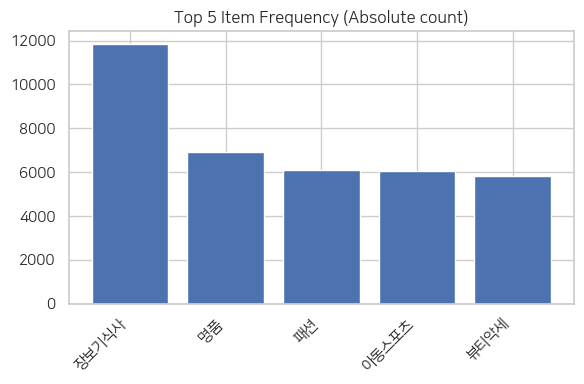

In [94]:
# =========================
# 3) itemFrequencyPlot(topN=5) 대체
# =========================
topN = 5
item_freq = trans_df.mean().sort_values(ascending=False)  # 각 아이템 등장 비율(=support)
top_items = item_freq.head(topN)

plt.figure(figsize=(6,4))
plt.bar(top_items.index, (top_items.values * len(trans_df)))  # "absolute" 느낌으로 건수로 표시
plt.title(f"Top {topN} Item Frequency (Absolute count)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [96]:
# =========================
# 4) Apriori: supp=0.001, conf=0.1, 길이 2(=A->B만)
# =========================
freq_itemsets = apriori(trans_df, min_support=0.001, use_colnames=True)

rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.1)

# 길이 2만 남기기: antecedents 1개 + consequents 1개
rules_2 = rules[
    (rules["antecedents"].apply(len) == 1) &
    (rules["consequents"].apply(len) == 1)
].copy()

# lift 상위 20개 보기
top_rules = rules_2.sort_values("lift", ascending=False).head(20)

# 보기 좋게 문자열로 변환
top_rules_out = top_rules.assign(
    antecedent=top_rules["antecedents"].apply(lambda s: list(s)[0]),
    consequent=top_rules["consequents"].apply(lambda s: list(s)[0]),
)[["antecedent","consequent","support","confidence","lift"]]

top_rules_out

,antecedent,consequent,support,confidence,lift
3,리빙합,뷰티악세,0.183900,0.541422,1.403916
2,뷰티악세,리빙합,0.183900,0.476854,1.403916
27,패션,아동스포츠,0.211176,0.521810,1.301331
26,아동스포츠,패션,0.211176,0.526647,1.301331
7,장보기식사,리빙합,0.268450,0.341985,1.006845
6,리빙합,장보기식사,0.268450,0.790348,1.006845
22,뷰티악세,패션,0.155362,0.402857,0.995448
23,패션,뷰티악세,0.155362,0.383896,0.995448
18,뷰티악세,아동스포츠,0.153902,0.399071,0.995233
19,아동스포츠,뷰티악세,0.153902,0.383813,0.995233


In [101]:
# =========================
# cluster 정보 load + join
# =========================
cluster_info = aggr_scaled

cluster_info["cust_id"] = cluster_info["cust_id"].astype(str)
cluster_info["cluster"] = pd.to_numeric(cluster_info["cluster"], errors="coerce")

df_joined = df_as.merge(cluster_info[["cust_id","cluster"]], on="cust_id", how="left")

def analyze_cluster_rules(cluster_num, supp=0.001, conf=0.1, top_k=5):
    print(f"\n\n========== cluster {cluster_num} ==========")

    df_cl = df_joined[df_joined["cluster"] == cluster_num].copy()
    if df_cl.empty:
        print("데이터 없음")
        return None

    # order_id 생성 (R과 동일)
    df_cl["order_id"] = df_cl["cust_id"].astype(str) + "_" + df_cl["date"].astype(str)

    basket_cl = (
        df_cl.groupby("order_id")["category"]
             .apply(lambda x: sorted(set(x.dropna().astype(str))))
             .reset_index(name="items")
    )

    # 트랜잭션 원-핫
    te = TransactionEncoder()
    te_ary = te.fit(basket_cl["items"]).transform(basket_cl["items"])
    trans = pd.DataFrame(te_ary, columns=te.columns_)

    # Apriori
    freq_itemsets = apriori(trans, min_support=supp, use_colnames=True)
    if freq_itemsets.empty:
        print("규칙없음 (빈발항목집합 없음)")
        return None

    rules = association_rules(freq_itemsets, metric="confidence", min_threshold=conf)

    # 길이 2 규칙만
    rules_2 = rules[
        (rules["antecedents"].apply(len) == 1) &
        (rules["consequents"].apply(len) == 1)
    ].copy()

    if rules_2.empty:
        print("규칙없음")
        return None

    out = (rules_2.sort_values("lift", ascending=False)
                 .head(top_k)
                 .assign(
                     antecedent=lambda d: d["antecedents"].apply(lambda s: list(s)[0]),
                     consequent=lambda d: d["consequents"].apply(lambda s: list(s)[0]),
                 )[["antecedent","consequent","support","confidence","lift"]])

    print(out)
    return out

# R의 for (k in c(1,2,3))
for k in [1,2,3]:
    analyze_cluster_rules(cluster_num=k, supp=0.001, conf=0.1, top_k=5)



========== cluster 1 ==========
   antecedent consequent   support  confidence      lift
2        뷰티악세        리빙합  0.138937    0.515924  1.617115
3         리빙합       뷰티악세  0.138937    0.435484  1.617115
27         패션      아동스포츠  0.137221    0.432432  1.355420
26      아동스포츠         패션  0.137221    0.430108  1.355420
7       장보기식사        리빙합  0.231561    0.346154  1.084988


========== cluster 2 ==========
   antecedent consequent   support  confidence      lift
3         리빙합       뷰티악세  0.184125    0.546181  1.407513
2        뷰티악세        리빙합  0.184125    0.474491  1.407513
27         패션      아동스포츠  0.212287    0.520748  1.335572
26      아동스포츠         패션  0.212287    0.544458  1.335572
18       뷰티악세      아동스포츠  0.153267    0.394970  1.012988


========== cluster 3 ==========
   antecedent consequent   support  confidence      lift
3         리빙합       뷰티악세  0.192593    0.544608  1.358725
2        뷰티악세        리빙합  0.192593    0.480493  1.358725
27         패션      아동스포츠  0.220576    0.539

In [105]:
df_association = aggr_rm.copy()

def unit_price(sales, cnt):
    return np.where(cnt == 0, 0, sales / cnt)

df_association["리빙건단가"] = unit_price(df_association["리빙합2"], df_association["리빙합"])
df_association["식사건단가"] = unit_price(df_association["장보기식사2"], df_association["장보기식사"])
df_association["명품건단가"] = unit_price(df_association["명품2"], df_association["명품"])
df_association["패션건단가"] = unit_price(df_association["패션2"], df_association["패션"])
df_association["아동건단가"] = unit_price(df_association["아동스포츠2"], df_association["아동스포츠"])
df_association["뷰티건단가"] = unit_price(df_association["뷰티악세2"], df_association["뷰티악세"])

# 클러스터별 평균 요약 (na는 자동 제외되도록 mean에서 skipna=True)
df_association_summary = (
    df_association.groupby("cluster")
    .agg(
        리빙건단가=("리빙건단가", "mean"),
        리빙건수=("리빙합", "mean"),
        식사건단가=("식사건단가", "mean"),
        식사건수=("장보기식사", "mean"),
        명품건단가=("명품건단가", "mean"),
        명품건수=("명품", "mean"),
        패션건단가=("패션건단가", "mean"),
        패션건수=("패션", "mean"),
        아동건단가=("아동건단가", "mean"),
        아동건수=("아동스포츠", "mean"),
        뷰티건단가=("뷰티건단가", "mean"),
        뷰티건수=("뷰티악세", "mean"),
    )
    .reset_index()
)

# 보기 좋게 반올림(원하면)
df_association_summary = df_association_summary.round(3)

df_association_summary

,cluster,리빙건단가,리빙건수,식사건단가,식사건수,명품건단가,명품건수,패션건단가,패션건수,아동건단가,아동건수,뷰티건단가,뷰티건수
0,1,47.081,9.073,22.671,65.612,8.756,36.539,51.505,15.814,49.904,18.032,168.979,5.047
1,2,19.211,22.499,3.816,185.192,4.733,43.048,20.620,39.743,19.716,34.535,3.917,27.470
2,3,31.112,12.500,22.896,71.836,2.641,39.665,45.358,25.070,38.333,23.980,8.508,17.689


- 배경: 오프라인 유통의 VVIP 고객 수 증가로 인한 CS 지속 발생, 고객 서비스 비용증가
- 목적:
  - 등급제의 목적, 문제 상황의 해결
 
- 현황: VVIP 고객 약 3,000만원 추가 구매여력 존재
- 분석:
- - 고객 구매 패턴 클러스터링(생활/가족/목적형 고객)
  - 클러스터별 최근 n년간의 구매 금액 데이터를 활용하여 선정기준 상향시, 추가 구매 가능 여부 판단

- 결론: 고객수최소/기회손실 최대 금액인 1.8억 새로운 등급 선정 기준 제안
  - 고객 서비스 비용 인단가 기준 //원 -> //원
  - 고객수 //명 -> //명
  - 매출 업셀링: //원(연간
    - 업셀링 위한 방안으로 연계 구매 쿠폰 지급 예정
      - 생활형 고객 //명, 예상 기대 매출//원, 예상 비용 //원
      - 가족형 고객 //명, 예상 기대 매출//원, 예상 비용 //원
      - 목적형 고객 //명, 예상 기대 매출//원, 예상 비용 //원